#Import Dataframes & Dataset

###Import Dataframe

In [ ]:
# Dataframe
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
%matplotlib inline

# Predictive model
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Install and use mlba for model evaluation
!pip install mlba
from mlba import classificationSummary

import seaborn as sns

import matplotlib.ticker as mticker

###Import Dataset

In [ ]:
df = pd.read_csv('Austin_Animal_Center_Outcomes.csv')

#Preprocessing & Cleaning

###Checking Data

In [ ]:
df.columns

Index(['Animal ID', 'Date of Birth', 'Name', 'DateTime', 'MonthYear',
       'Outcome Type', 'Outcome Subtype', 'Animal Type', 'Sex upon Outcome',
       'Age upon Outcome', 'Breed', 'Color'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 173775 entries, 0 to 173774
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Animal ID         173775 non-null  object
 1   Date of Birth     173775 non-null  object
 2   Name              123991 non-null  object
 3   DateTime          173775 non-null  object
 4   MonthYear         173775 non-null  object
 5   Outcome Type      173729 non-null  object
 6   Outcome Subtype   79660 non-null   object
 7   Animal Type       173775 non-null  object
 8   Sex upon Outcome  173774 non-null  object
 9   Age upon Outcome  173766 non-null  object
 10  Breed             173775 non-null  object
 11  Color             173775 non-null  object
dtypes: object(12)
memory usage: 15.9+ MB


###Clean the Data

In [ ]:
#Cleaning the data
#replacing blanks with _ in column names
df = df.rename(columns={'Animal ID': 'Animal_ID', 'Date of Birth': 'Date_of_Birth', 'DateTime': 'Date_Time','MonthYear': 'Month_Year', 'Outcome Type': 'Outcome_Type', 'Animal Type': 'Animal_Type', 'Sex upon Outcome': 'Sex_upon_Outcome', 'Age upon Outcome' : 'Age_upon_Outcome' })

#replacing null values with None or Remaining
df.fillna({'Name':'Unknown','Outcome_Subtype':'Unknown'},inplace=True)

#dropping null values
df.dropna(subset=['Outcome_Type','Sex_upon_Outcome','Age_upon_Outcome'], inplace=True)

#Remove negative age values
df = df[df['Age_upon_Outcome'].str.contains('-') == False]

#Drop Duplicates
df = df.drop_duplicates()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 173683 entries, 0 to 173774
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Animal_ID         173683 non-null  object
 1   Date_of_Birth     173683 non-null  object
 2   Name              173683 non-null  object
 3   Date_Time         173683 non-null  object
 4   Month_Year        173683 non-null  object
 5   Outcome_Type      173683 non-null  object
 6   Outcome Subtype   79635 non-null   object
 7   Animal_Type       173683 non-null  object
 8   Sex_upon_Outcome  173683 non-null  object
 9   Age_upon_Outcome  173683 non-null  object
 10  Breed             173683 non-null  object
 11  Color             173683 non-null  object
dtypes: object(12)
memory usage: 17.2+ MB


#General Animal Center Data

###Distribution of Animal Types

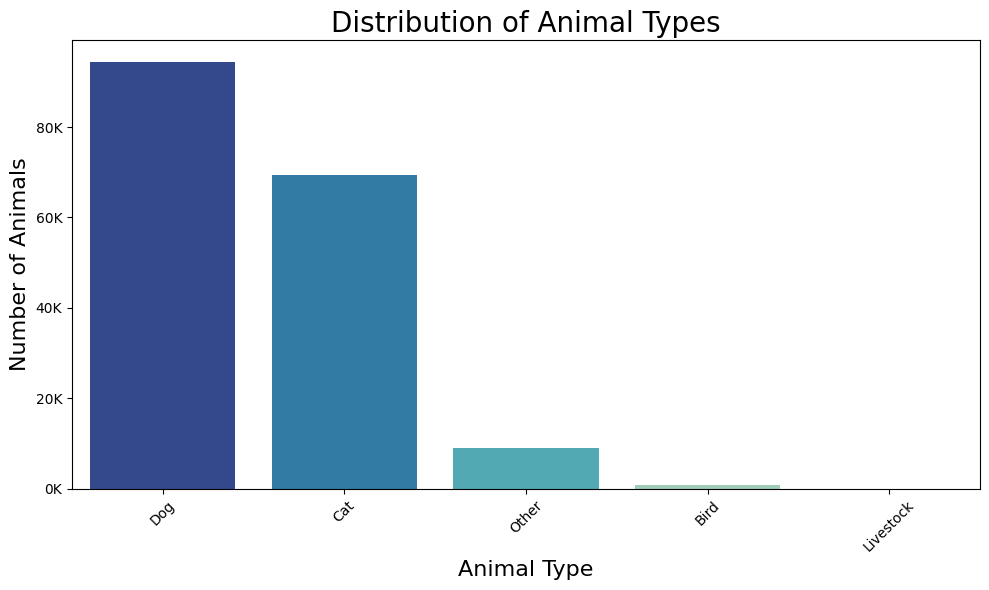

In [ ]:
animal_type_counts = df['Animal_Type'].value_counts().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=animal_type_counts.index, y=animal_type_counts.values, hue=animal_type_counts.index, palette='YlGnBu_r', legend=False)

def y_fmt(y, pos):
    return f'{y/1000:.0f}K'

y_formatter = mticker.FuncFormatter(y_fmt)
ax.yaxis.set_major_formatter(y_formatter)

plt.title('Distribution of Animal Types', fontsize = "20")
plt.xlabel('Animal Type', fontsize = "16")
plt.ylabel('Number of Animals', fontsize = "16")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

###Distribution of Outcomes (ALL ANIMALS)

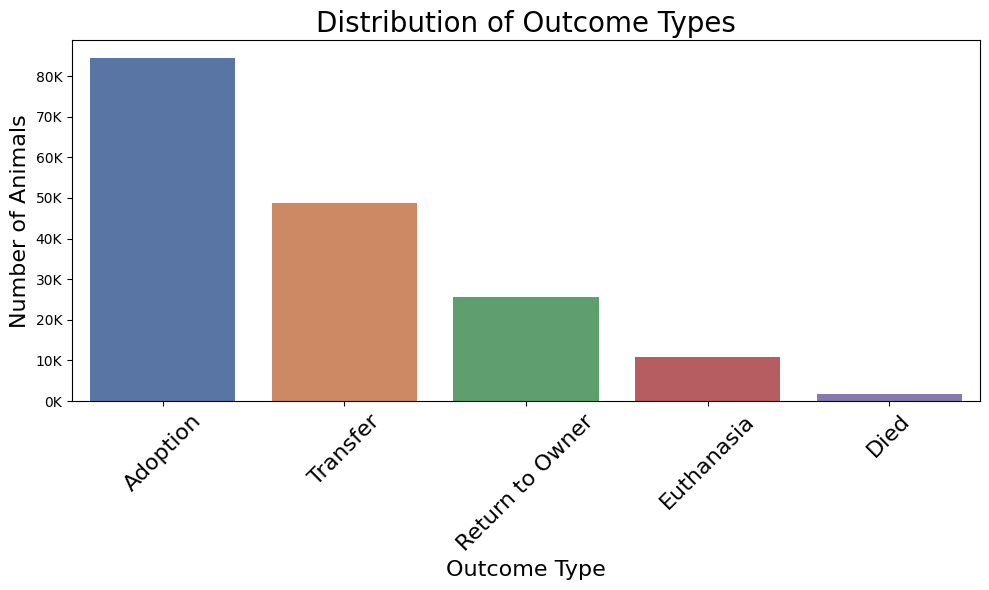

In [ ]:
outcomes_to_remove = ['Missing', 'Waiting', 'Stolen', 'Relocate', 'Lost']
df_filtered_for_plot = df[~df['Outcome_Type'].isin(outcomes_to_remove)]

outcome_type_counts = df_filtered_for_plot['Outcome_Type'].value_counts().head(5)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=outcome_type_counts.index, y=outcome_type_counts.values, hue=outcome_type_counts.index, palette='deep', legend=False)

def y_fmt(y, pos):
    return f'{y/1000:.0f}K'

y_formatter = mticker.FuncFormatter(y_fmt)
ax.yaxis.set_major_formatter(y_formatter)

plt.title('Distribution of Outcome Types', fontsize = "20")
plt.xlabel('Outcome Type', fontsize = "16")
plt.ylabel('Number of Animals', fontsize = "16")
plt.xticks(rotation=45, fontsize = "16")
plt.tight_layout()
plt.show()

###Distribution of Outcomes for Dogs

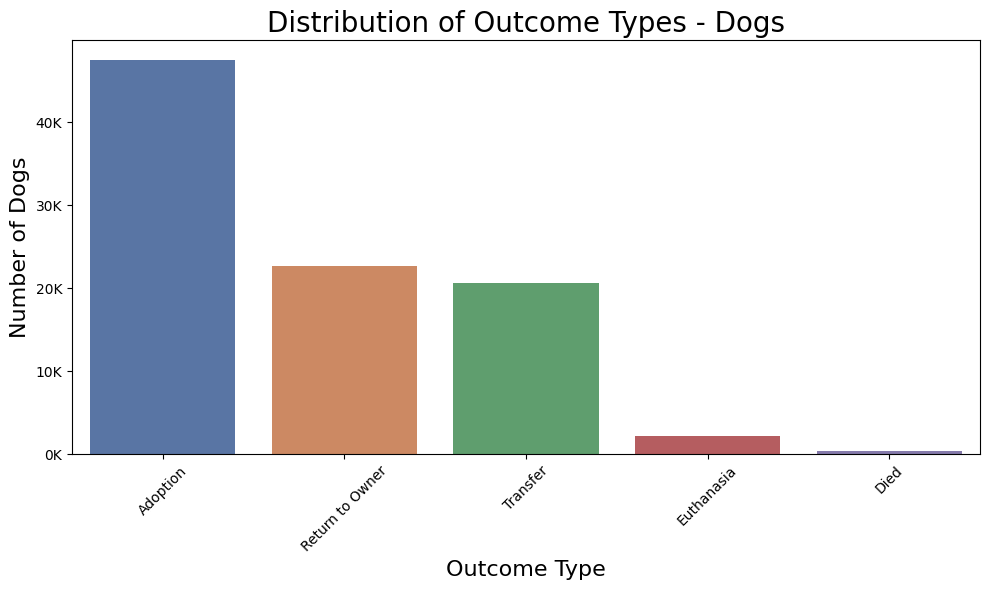

In [ ]:
outcomes_to_exclude = ['Disposal', 'Missing', 'Waiting', 'Stolen', 'Relocate', 'Lost', 'Rto-Adopt']
dog_outcomes = df[df['Animal_Type'] == 'Dog']['Outcome_Type'].value_counts()
dog_outcomes_filtered = dog_outcomes.drop(labels=outcomes_to_exclude, errors='ignore')

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=dog_outcomes_filtered.index, y=dog_outcomes_filtered.values, hue=dog_outcomes_filtered.index, palette='deep', legend=False)

def y_fmt(y, pos):
    return f'{y/1000:.0f}K'

y_formatter = mticker.FuncFormatter(y_fmt)
ax.yaxis.set_major_formatter(y_formatter)

plt.title('Distribution of Outcome Types - Dogs', fontsize = "20")
plt.xlabel('Outcome Type', fontsize = "16")
plt.ylabel('Number of Dogs', fontsize = "16")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Distribution of Age upon Outcome

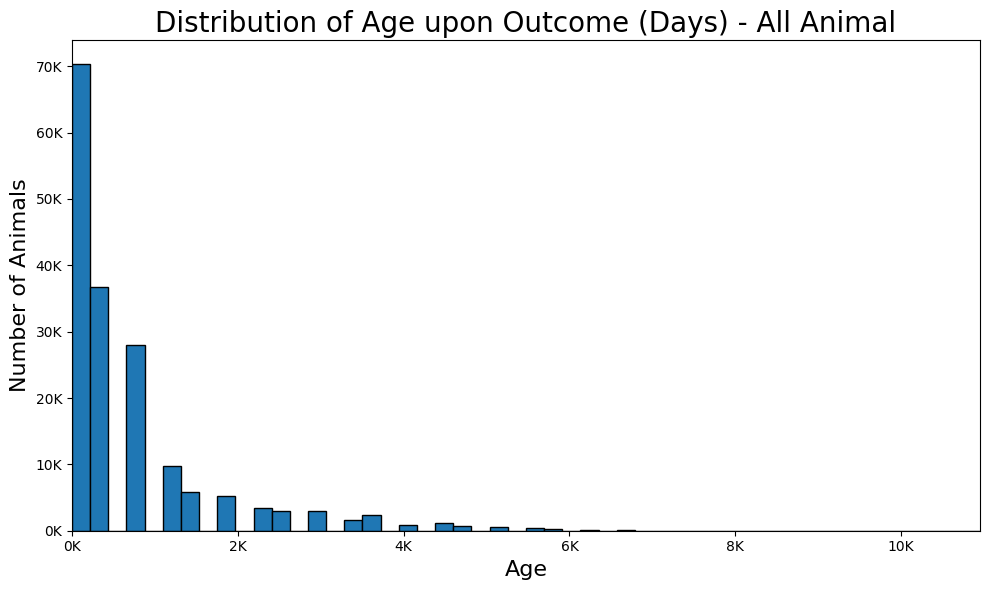

In [ ]:
df['Date_of_Birth'] = pd.to_datetime(df['Date_of_Birth'])
df['Date_Time'] = pd.to_datetime(df['Date_Time'], format='ISO8601')
df['Sex_upon_Outcome'] = df['Sex_upon_Outcome'].fillna('Unknown')

def convert_age_to_days(age_str):
    if pd.isna(age_str):
        return None
    age_str = str(age_str).lower()
    num, unit = age_str.split(' ', 1)
    num = int(num)
    if 'year' in unit:
        return num * 365
    elif 'month' in unit:
        return num * 30
    elif 'week' in unit:
        return num * 7
    elif 'day' in unit:
        return num
    return None

df['Age_in_Days'] = df['Age_upon_Outcome'].apply(convert_age_to_days)
df['Outcome_Year'] = df['Date_Time'].dt.year
df['Outcome_Month'] = df['Date_Time'].dt.month

plt.figure(figsize=(10, 6))
plt.hist(df['Age_in_Days'].dropna(), bins=50, edgecolor='black')


ax = plt.gca()

def y_fmt(y, pos):
    return f'{y/1000:.0f}K'

y_formatter = mticker.FuncFormatter(y_fmt)
ax.yaxis.set_major_formatter(y_formatter)

def x_fmt(x, pos):
    return f'{x/1000:.0f}K'

x_formatter = mticker.FuncFormatter(x_fmt)
ax.xaxis.set_major_formatter(x_formatter)

plt.title('Distribution of Age upon Outcome (Days) - All Animal', fontsize = "20")
plt.xlabel('Age', fontsize = "16")
plt.ylabel('Number of Animals', fontsize = "16")
plt.xlim(0, df['Age_in_Days'].max())
plt.tight_layout()
plt.show()

###Distribution of Age upon Outcome for dogs

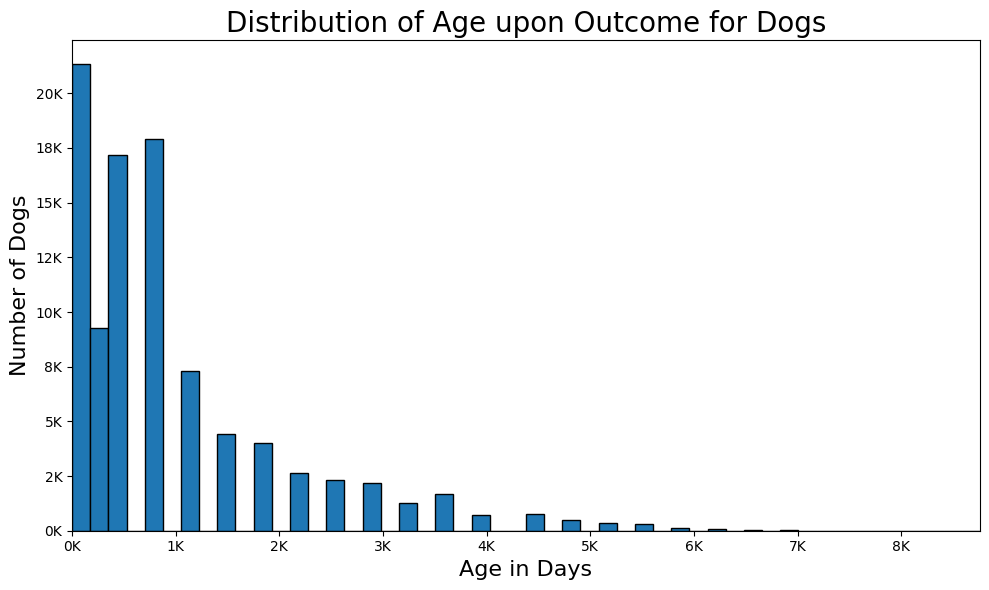

In [ ]:
dog_age_data = df[df['Animal_Type'] == 'Dog']['Age_in_Days'].dropna()

plt.figure(figsize=(10, 6))
ax = plt.hist(dog_age_data, bins=50, edgecolor='black')

ax = plt.gca()

def y_fmt(y, pos):
    return f'{y/1000:.0f}K'

y_formatter = mticker.FuncFormatter(y_fmt)
ax.yaxis.set_major_formatter(y_formatter)

def x_fmt(x, pos):
    return f'{x/1000:.0f}K'

x_formatter = mticker.FuncFormatter(x_fmt)
ax.xaxis.set_major_formatter(x_formatter)

plt.title('Distribution of Age upon Outcome for Dogs', fontsize = "20")
plt.xlabel('Age in Days', fontsize = "16")
plt.ylabel('Number of Dogs', fontsize = "16")
plt.xlim(0, dog_age_data.max())
plt.tight_layout()
plt.show()

###Breed Distribution

####Long Breed Categorization & Cleaning Code

In [ ]:
# 1. DOGS ONLY
df_dogs_breeds = df[df['Animal_Type'].astype(str).str.strip().str.lower() == 'dog'].copy()
df_dogs_breeds['Breed'] = df_dogs_breeds['Breed'].fillna('Unknown').astype(str).str.strip()

# 2. CLEAN PRIMARY BREED
def clean_breed_name(breed):
    breed = str(breed).strip()

    if breed == '' or breed.lower() == 'nan':
        return 'Unknown'

    primary = breed.split('/')[0].strip()
    primary = primary.replace(' Mix', '').replace(' mix', '').strip()
    primary = ' '.join(primary.split())

    return primary

df_dogs_breeds['Breed_clean'] = df_dogs_breeds['Breed'].apply(clean_breed_name)

# 3. EXACT BREED / ALIAS MAP
breed_to_category = {
    "Pit Bull": "Bully",
    "American Pit Bull Terrier": "Bully",
    "American Staffordshire Terrier": "Bully",
    "Staffordshire Bull Terrier": "Bully",
    "Staffordshire": "Bully",
    "American Bulldog": "Bully",
    "Bulldog": "Bully",
    "English Bulldog": "Bully",
    "French Bulldog": "Bully",
    "Old English Bulldog": "Bully",
    "Bull Terrier": "Bully",
    "Miniature Bull Terrier": "Bully",
    "American Bully": "Bully",

    "Labrador Retriever": "Retriever",
    "Lab": "Retriever",
    "Golden Retriever": "Retriever",
    "Flat Coat Retriever": "Retriever",
    "Curly Coat Retriever": "Retriever",
    "Chesapeake Bay Retriever": "Retriever",
    "Nova Scotia Duck Tolling Retriever": "Retriever",

    "German Shepherd": "Shepherd",
    "German Shepherd Dog": "Shepherd",
    "Australian Shepherd": "Shepherd",
    "Australian Cattle Dog": "Shepherd",
    "Queensland Heeler": "Shepherd",
    "Blue Heeler": "Shepherd",
    "Red Heeler": "Shepherd",
    "Belgian Malinois": "Shepherd",
    "Belgian Sheepdog": "Shepherd",
    "Belgian Tervuren": "Shepherd",
    "Dutch Shepherd": "Shepherd",
    "Anatol Shepherd": "Shepherd",
    "Anatolian Shepherd": "Shepherd",
    "Border Collie": "Shepherd",
    "Collie Rough": "Shepherd",
    "Collie Smooth": "Shepherd",
    "Shetland Sheepdog": "Shepherd",
    "Old English Sheepdog": "Shepherd",
    "Australian Kelpie": "Shepherd",
    "Corgi": "Shepherd",
    "Pembroke Welsh Corgi": "Shepherd",
    "Cardigan Welsh Corgi": "Shepherd",
    "Beauceron": "Shepherd",
    "Briard": "Shepherd",
    "Bouvier Des Flandres": "Shepherd",
    "Mudi": "Shepherd",

    "Beagle": "Hound",
    "Basset Hound": "Hound",
    "Bloodhound": "Hound",
    "Dachshund": "Hound",
    "Dachshund Longhair": "Hound",
    "Dachshund Wirehair": "Hound",
    "Miniature Dachshund": "Hound",
    "Greyhound": "Hound",
    "Whippet": "Hound",
    "Afghan Hound": "Hound",
    "Borzoi": "Hound",
    "Irish Wolfhound": "Hound",
    "Plott Hound": "Hound",
    "American Foxhound": "Hound",
    "Redbone Hound": "Hound",
    "Bluetick Hound": "Hound",
    "Black And Tan Coonhound": "Hound",
    "Treeing Walker Coonhound": "Hound",
    "Harrier": "Hound",
    "Rhodesian Ridgeback": "Hound",
    "Saluki": "Hound",
    "Otterhound": "Hound",
    "Ibizan Hound": "Hound",
    "Pharaoh Hound": "Hound",

    "Jack Russell Terrier": "Terrier",
    "Parson Russell Terrier": "Terrier",
    "Rat Terrier": "Terrier",
    "Cairn Terrier": "Terrier",
    "Border Terrier": "Terrier",
    "Scottish Terrier": "Terrier",
    "West Highland": "Terrier",
    "West Highland White Terrier": "Terrier",
    "Yorkshire Terrier": "Terrier",
    "Airedale Terrier": "Terrier",
    "Australian Terrier": "Terrier",
    "Norfolk Terrier": "Terrier",
    "Norwich Terrier": "Terrier",
    "Bedlington Terrier": "Terrier",
    "Irish Terrier": "Terrier",
    "Welsh Terrier": "Terrier",
    "Lakeland Terrier": "Terrier",
    "Fox Terrier": "Terrier",
    "Wire Hair Fox Terrier": "Terrier",
    "Sealyham Terrier": "Terrier",
    "Soft Coated Wheaten Terrier": "Terrier",
    "Dandie Dinmont Terrier": "Terrier",
    "American Hairless Terrier": "Terrier",
    "Treeing Feist": "Terrier",

    "Chihuahua": "Toy/Companion",
    "Chihuahua Shorthair": "Toy/Companion",
    "Chihuahua Longhair": "Toy/Companion",
    "Pomeranian": "Toy/Companion",
    "Maltese": "Toy/Companion",
    "Shih Tzu": "Toy/Companion",
    "Pekingese": "Toy/Companion",
    "Papillon": "Toy/Companion",
    "Bruss Griffon": "Toy/Companion",
    "Brussels Griffon": "Toy/Companion",
    "Chinese Crested": "Toy/Companion",
    "Miniature Pinscher": "Toy/Companion",
    "Italian Greyhound": "Toy/Companion",
    "Toy Poodle": "Toy/Companion",
    "Pug": "Toy/Companion",
    "Havanese": "Toy/Companion",
    "Lhasa Apso": "Toy/Companion",
    "Bichon Frise": "Toy/Companion",
    "Coton De Tulear": "Toy/Companion",
    "Japanese Chin": "Toy/Companion",
    "Cavalier King Charles Spaniel": "Toy/Companion",
    "English Toy Spaniel": "Toy/Companion",
    "Affenpinscher": "Toy/Companion",
    "Silkie": "Toy/Companion",

    "Siberian Husky": "Spitz/Northern",
    "Alaskan Husky": "Spitz/Northern",
    "Alaskan Klee Kai": "Spitz/Northern",
    "Alaskan Malamute": "Spitz/Northern",
    "Akita": "Spitz/Northern",
    "Samoyed": "Spitz/Northern",
    "Shiba Inu": "Spitz/Northern",
    "American Eskimo": "Spitz/Northern",
    "Chow Chow": "Spitz/Northern",
    "Keeshond": "Spitz/Northern",
    "Finnish Spitz": "Spitz/Northern",
    "Norwegian Elkhound": "Spitz/Northern",
    "Icelandic Sheepdog": "Spitz/Northern",
    "Finnish Lapphund": "Spitz/Northern",
    "Swedish Vallhund": "Spitz/Northern",

    "Rottweiler": "Working",
    "Doberman Pinsch": "Working",
    "Doberman Pinscher": "Working",
    "Mastiff": "Working",
    "Bullmastiff": "Working",
    "Great Dane": "Working",
    "Saint Bernard": "Working",
    "St. Bernard": "Working",
    "Newfoundland": "Working",
    "Cane Corso": "Working",
    "Boerboel": "Working",
    "Akbash": "Working",
    "Komondor": "Working",
    "Kuvasz": "Working",
    "Leonberger": "Working",
    "Neapolitan Mastiff": "Working",
    "Dogo Argentino": "Working",
    "Black Russian Terrier": "Working",
    "Giant Schnauzer": "Working",
    "Tibetan Mastiff": "Working",
    "Great Pyrenees": "Working",

    "Cocker Spaniel": "Sporting",
    "English Cocker Spaniel": "Sporting",
    "English Springer Spaniel": "Sporting",
    "Springer Spaniel": "Sporting",
    "Boykin Spaniel": "Sporting",
    "Field Spaniel": "Sporting",
    "Brittany": "Sporting",
    "Pointer": "Sporting",
    "German Shorthaired Pointer": "Sporting",
    "German Wirehaired Pointer": "Sporting",
    "Vizsla": "Sporting",
    "Wirehaired Vizsla": "Sporting",
    "Weimaraner": "Sporting",
    "Irish Setter": "Sporting",
    "English Setter": "Sporting",
    "Gordon Setter": "Sporting",
    "Clumber Spaniel": "Sporting",
    "Sussex Spaniel": "Sporting",
    "Wirehaired Pointing Griffon": "Sporting",
    "Spinone Italiano": "Sporting",

    "Bernese Mountain Dog": "Mountain",
    "Greater Swiss Mountain Dog": "Mountain",
    "Entlebucher": "Mountain",
    "Entlebucher Mountain Dog": "Mountain",
    "Appenzeller Sennenhnd": "Mountain",
    "Appenzeller Sennenhund": "Mountain",

    "Black Mouth Cur": "Cur / Regional",
    "Catahoula": "Cur / Regional",
    "Catahoula Leopard Dog": "Cur / Regional",
    "Blue Lacy": "Cur / Regional",
    "Mountain Cur": "Cur / Regional",
    "Treeing Cur": "Cur / Regional",

    "Basenji": "Primitive",
    "Carolina Dog": "Primitive",
    "Xoloitzcuintli": "Primitive",
    "Peruvian Inca Orchid": "Primitive",
    "Thai Ridgeback": "Primitive",

    "Sharpei": "Asian / Guardian",
    "Chinese Sharpei": "Asian / Guardian",
    "Tosa": "Asian / Guardian",

    "Poodle": "Poodle",
    "Toy Poodle": "Poodle",
    "Miniature Poodle": "Poodle",
    "Standard Poodle": "Poodle",

    "Miniature Schnauzer": "Schnauzer",
    "Standard Schnauzer": "Schnauzer",
    "Giant Schnauzer": "Schnauzer",

    "Dalmatian": "Dalmatian",
    "Wolf Hybrid": "Wolf Hybrid"
}

# 4. KEYWORD RULES
keyword_rules = [
    ("staffordshire", "Bully"),
    ("pit bull", "Bully"),
    ("american bully", "Bully"),
    ("bulldog", "Bully"),
    ("bull terrier", "Bully"),
    ("boxer", "Bully"),

    ("labrador", "Retriever"),
    ("lab", "Retriever"),
    ("retriever", "Retriever"),
    ("golden", "Retriever"),
    ("chesapeake", "Retriever"),
    ("flat coat", "Retriever"),
    ("curly coat", "Retriever"),
    ("tolling", "Retriever"),

    ("german shepherd", "Shepherd"),
    ("shepherd", "Shepherd"),
    ("malinois", "Shepherd"),
    ("cattle dog", "Shepherd"),
    ("heeler", "Shepherd"),
    ("kelpie", "Shepherd"),
    ("collie", "Shepherd"),
    ("sheepdog", "Shepherd"),
    ("corgi", "Shepherd"),
    ("briard", "Shepherd"),
    ("beauceron", "Shepherd"),
    ("bouvier", "Shepherd"),
    ("mudi", "Shepherd"),

    ("hound", "Hound"),
    ("beagle", "Hound"),
    ("dachshund", "Hound"),
    ("greyhound", "Hound"),
    ("whippet", "Hound"),
    ("coonhound", "Hound"),
    ("ridgeback", "Hound"),
    ("saluki", "Hound"),
    ("borzoi", "Hound"),
    ("afghan", "Hound"),
    ("basset", "Hound"),
    ("bloodhound", "Hound"),
    ("foxhound", "Hound"),
    ("wolfhound", "Hound"),
    ("otterhound", "Hound"),

    ("terrier", "Terrier"),
    ("feist", "Terrier"),

    ("chihuahua", "Toy/Companion"),
    ("pomeranian", "Toy/Companion"),
    ("maltese", "Toy/Companion"),
    ("shih tzu", "Toy/Companion"),
    ("pekingese", "Toy/Companion"),
    ("papillon", "Toy/Companion"),
    ("griffon", "Toy/Companion"),
    ("crested", "Toy/Companion"),
    ("pug", "Toy/Companion"),
    ("havanese", "Toy/Companion"),
    ("lhasa", "Toy/Companion"),
    ("bichon", "Toy/Companion"),
    ("coton", "Toy/Companion"),
    ("pinscher", "Toy/Companion"),
    ("affenpinscher", "Toy/Companion"),

    ("spaniel", "Sporting"),

    ("husky", "Spitz/Northern"),
    ("malamute", "Spitz/Northern"),
    ("akita", "Spitz/Northern"),
    ("samoyed", "Spitz/Northern"),
    ("shiba", "Spitz/Northern"),
    ("eskimo", "Spitz/Northern"),
    ("chow", "Spitz/Northern"),
    ("keeshond", "Spitz/Northern"),
    ("spitz", "Spitz/Northern"),
    ("elkhound", "Spitz/Northern"),
    ("klee kai", "Spitz/Northern"),

    ("rottweiler", "Working"),
    ("doberman", "Working"),
    ("mastiff", "Working"),
    ("great dane", "Working"),
    ("newfoundland", "Working"),
    ("saint bernard", "Working"),
    ("st. bernard", "Working"),
    ("cane corso", "Working"),
    ("boerboel", "Working"),
    ("akbash", "Working"),
    ("komondor", "Working"),
    ("kuvasz", "Working"),
    ("leonberger", "Working"),
    ("dogo argentino", "Working"),
    ("black russian terrier", "Working"),

    ("pointer", "Sporting"),
    ("setter", "Sporting"),
    ("vizsla", "Sporting"),
    ("weimaraner", "Sporting"),
    ("brittany", "Sporting"),
    ("spinone", "Sporting"),

    ("mountain dog", "Mountain"),
    ("sennenhund", "Mountain"),
    ("entlebucher", "Mountain"),
    ("appenzeller", "Mountain"),

    ("cur", "Cur / Regional"),
    ("catahoula", "Cur / Regional"),
    ("lacy", "Cur / Regional"),

    ("basenji", "Primitive"),
    ("carolina dog", "Primitive"),
    ("xolo", "Primitive"),
    ("inca orchid", "Primitive"),
    ("thai ridgeback", "Primitive"),

    ("sharpei", "Asian / Guardian"),
    ("shar pei", "Asian / Guardian"),
    ("tosa", "Asian / Guardian"),

    ("poodle", "Poodle"),
    ("doodle", "Poodle Mix"),

    ("schnauzer", "Schnauzer"),

    ("dalmatian", "Dalmatian"),
    ("wolf hybrid", "Wolf Hybrid")
]

# 5. CATEGORY FUNCTION
def categorize_dog_breed(breed):
    breed = str(breed).strip()

    if breed == '' or breed.lower() == 'nan':
        return 'Unknown'

    if breed in breed_to_category:
        return breed_to_category[breed]

    breed_lower = breed.lower()

    for keyword, category in keyword_rules:
        if keyword in breed_lower:
            return category

    return breed

df_dogs_breeds['Breed_Category'] = df_dogs_breeds['Breed_clean'].apply(categorize_dog_breed)

# 6. OPTIONAL CHECKS
print(df_dogs_breeds[['Breed', 'Breed_clean', 'Breed_Category']].head(20))

remaining = (
    df_dogs_breeds[df_dogs_breeds['Breed_Category'] == df_dogs_breeds['Breed_clean']]['Breed_clean']
    .value_counts()
    .head(100)
)

print(remaining)

print(
    df_dogs_breeds[df_dogs_breeds['Breed_Category'] == df_dogs_breeds['Breed_clean']]['Breed_clean']
    .value_counts()
    .head(200)
)

                                  Breed                Breed_clean  \
12                  Black Mouth Cur Mix            Black Mouth Cur   
21              Chihuahua Shorthair Mix        Chihuahua Shorthair   
23                        Shiba Inu Mix                  Shiba Inu   
26                   Cocker Spaniel Mix             Cocker Spaniel   
27              Chihuahua Shorthair Mix        Chihuahua Shorthair   
30        American Pit Bull Terrier Mix  American Pit Bull Terrier   
31  Golden Retriever/Labrador Retriever           Golden Retriever   
32              Chihuahua Shorthair Mix        Chihuahua Shorthair   
34                   Miniature Pinscher         Miniature Pinscher   
35                  Chihuahua Shorthair        Chihuahua Shorthair   
36                         Pit Bull Mix                   Pit Bull   
37               Labrador Retriever Mix         Labrador Retriever   
38                         Havanese Mix                   Havanese   
39                  

####Graphs with Breeds

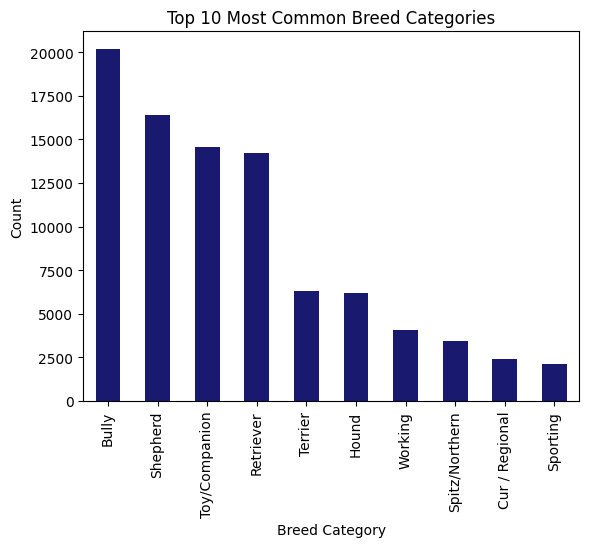

In [ ]:
top_breed_categories = df_dogs_breeds['Breed_Category'].value_counts().head(10)

top_breed_categories.plot.bar(color='midnightblue')

plt.title("Top 10 Most Common Breed Categories")
plt.xlabel("Breed Category")
plt.ylabel("Count")
plt.show()

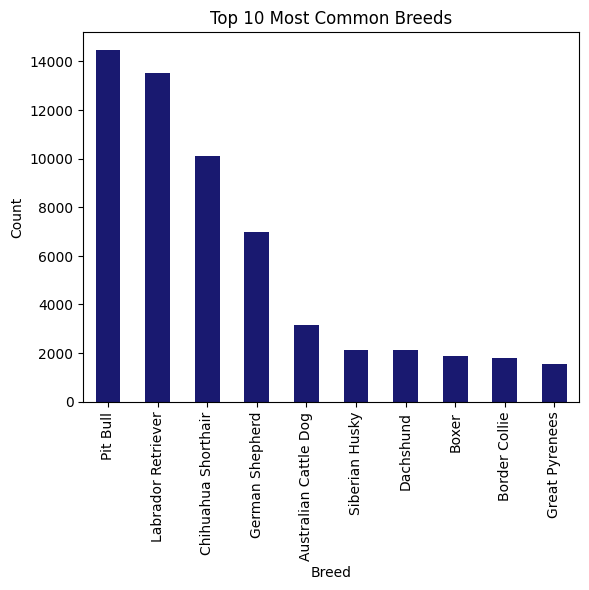

In [ ]:
top_breeds = df_dogs_breeds['Breed_clean'].value_counts().head(10)

top_breeds.plot.bar(color='midnightblue')

plt.title("Top 10 Most Common Breeds")
plt.xlabel("Breed")
plt.ylabel("Count")
plt.show()

#Adoption Rates and Patterns for dogs

###Adoption Rate By Breed

#### Adoption Rate for Bully Breeds

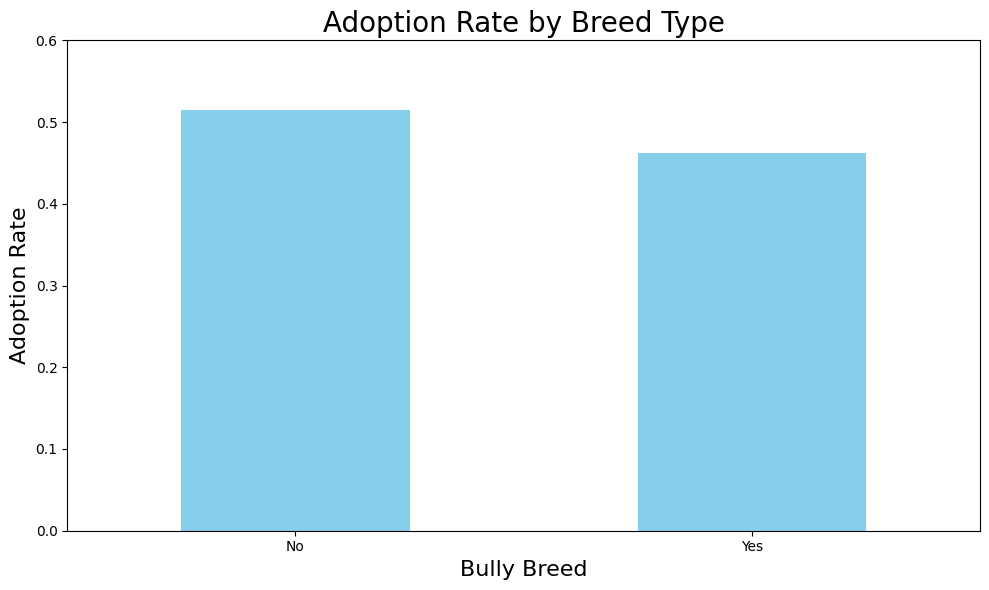

In [ ]:
#Dogs only dataset
df_dogs = df[df['Animal_Type'] == 'Dog'].copy()

import numpy as np
#defining bully breeds
bully_breeds_keywords = ['pit bull', 'staffordshire', 'am staff','bulldog', 'american bulldog', 'presa canario',
'cane corso', 'american pit bull terrier','american bully','dogo argentino', 'fila brasileiro', 'bandog', 'bull terrier', 'mastiff', 'boxer']

bully_flag = []

for i in df_dogs['Breed']:
  lower_breed = str(i).lower()
  is_bully_breed = 0
  for keyword in bully_breeds_keywords:
    if keyword in lower_breed:
      is_bully_breed = 1
      break

  bully_flag.append(is_bully_breed)

df_dogs['Is_Bully'] = bully_flag

df_dogs[df_dogs['Is_Bully'] == 1]['Breed'].value_counts().head(20)

#Change the 0 and 1 to No and Yes
df_dogs['Bully_Clean'] = df_dogs['Is_Bully'].replace({0: 'No', 1: 'Yes'})

#Set Adopted Animal Labels
df_dogs['Adoption_Flag'] = (df_dogs['Outcome_Type'].isin(["Adoption",'RTO-Adopt']))

#Create Adoption Percentages of Bully Breed
adoption_rate_bully = pd.crosstab(df_dogs.Bully_Clean, df_dogs.Adoption_Flag, normalize='index')[True]

#Create the bar plot
plt.figure(figsize=(10, 6))
adoption_rate_bully.plot.bar(color='skyblue')
plt.title("Adoption Rate by Breed Type",fontsize = 20)
plt.xlabel("Bully Breed", fontsize= 16)
plt.ylabel("Adoption Rate", fontsize = 16)
plt.yticks([0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6])
plt.xticks(rotation=0, ha ='center')
plt.tight_layout()
plt.show()

####Adoption Rate by Breed & Breed Category

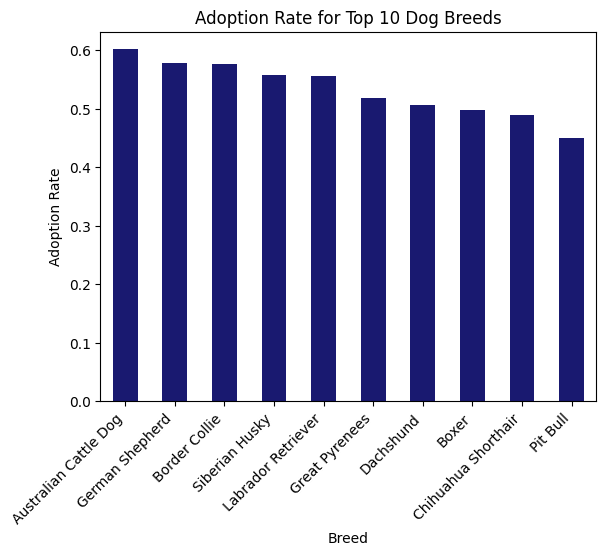

In [ ]:
#New Adoption Flag
df_dogs_breeds['Adoption_Flag'] = (df_dogs_breeds['Outcome_Type'].isin(["Adoption",'RTO-Adopt']))

# top 10 breeds by count
top_breeds = df_dogs_breeds['Breed_clean'].value_counts().head(10).index

# adoption rate for those breeds
adoption_rate_breeds = (
    df_dogs_breeds[df_dogs_breeds['Breed_clean'].isin(top_breeds)]
    .groupby('Breed_clean')['Adoption_Flag']
    .mean())

# plot
adoption_rate_breeds.sort_values(ascending=False).plot.bar(color='midnightblue')

plt.title("Adoption Rate for Top 10 Dog Breeds")
plt.xlabel("Breed")
plt.ylabel("Adoption Rate")
plt.xticks(rotation=45, ha='right')
plt.show()

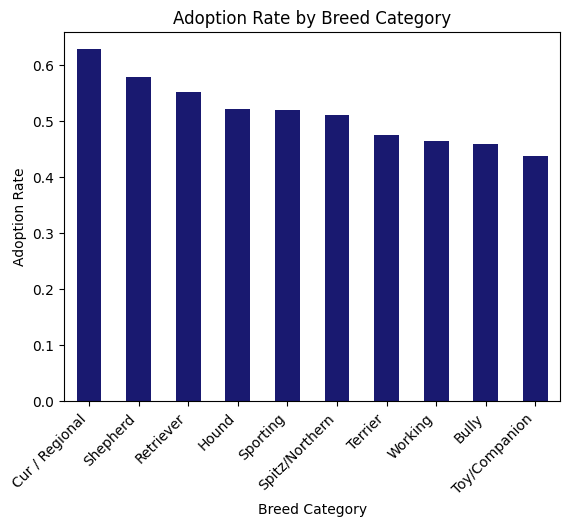

In [ ]:
# top 10 breed categories
top_categories = df_dogs_breeds['Breed_Category'].value_counts().head(10).index

# adoption rate
adoption_rate_categories = (
    df_dogs_breeds[df_dogs_breeds['Breed_Category'].isin(top_categories)]
    .groupby('Breed_Category')['Adoption_Flag']
    .mean())


# plot
adoption_rate_categories.sort_values(ascending=False).plot.bar(color='midnightblue')

plt.title("Adoption Rate by Breed Category")
plt.xlabel("Breed Category")
plt.ylabel("Adoption Rate")
plt.xticks(rotation=45, ha='right')
plt.show()

###Adoption Rate by Age

In [ ]:
#Part of Cleaning:
#Double check and remove negative age values
df_dogs = df_dogs[df_dogs['Age_upon_Outcome'].str.contains('-') == False]

age_map = {

# 6 months or less
'0 years':'6 months or less',
'1 day':'6 months or less',
'2 days':'6 months or less',
'3 days':'6 months or less',
'4 days':'6 months or less',
'5 days':'6 months or less',
'6 days':'6 months or less',
'1 week':'6 months or less',
'1 weeks':'6 months or less',
'2 weeks':'6 months or less',
'3 weeks':'6 months or less',
'4 weeks':'6 months or less',
'5 weeks':'6 months or less',
'1 month':'6 months or less',
'2 months':'6 months or less',
'3 months':'6 months or less',
'4 months':'6 months or less',
'5 months':'6 months or less',
'6 months':'6 months or less',

# 6 months to 1 year
'7 months':'6mos-1 year',
'8 months':'6mos-1 year',
'9 months':'6mos-1 year',
'10 months':'6mos-1 year',
'11 months':'6mos-1 year',

# 1-3 years
'1 year':'1-3 years',
'2 years':'1-3 years',
'3 years':'1-3 years',

# 4-7 years
'4 years':'4-7 years',
'5 years':'4-7 years',
'6 years':'4-7 years',
'7 years':'4-7 years',

# above 7 years
'8 years':'Above 7 years',
'9 years':'Above 7 years',
'10 years':'Above 7 years',
'11 years':'Above 7 years',
'12 years':'Above 7 years',
'13 years':'Above 7 years',
'14 years':'Above 7 years',
'15 years':'Above 7 years',
'16 years':'Above 7 years',
'17 years':'Above 7 years',
'18 years':'Above 7 years',
'19 years':'Above 7 years',
'20 years':'Above 7 years',
'21 years':'Above 7 years',
'22 years':'Above 7 years',
'23 years':'Above 7 years',
'24 years':'Above 7 years',
'25 years':'Above 7 years',
'28 years':'Above 7 years',
'30 years':'Above 7 years'}


df_dogs['Age_Categorized'] = df_dogs['Age_upon_Outcome'].map(age_map)

#Define the Order
order = ['6 months or less','6mos-1 year','1-3 years','4-7 years','Above 7 years']

###### Count Adopted Dogs by Age

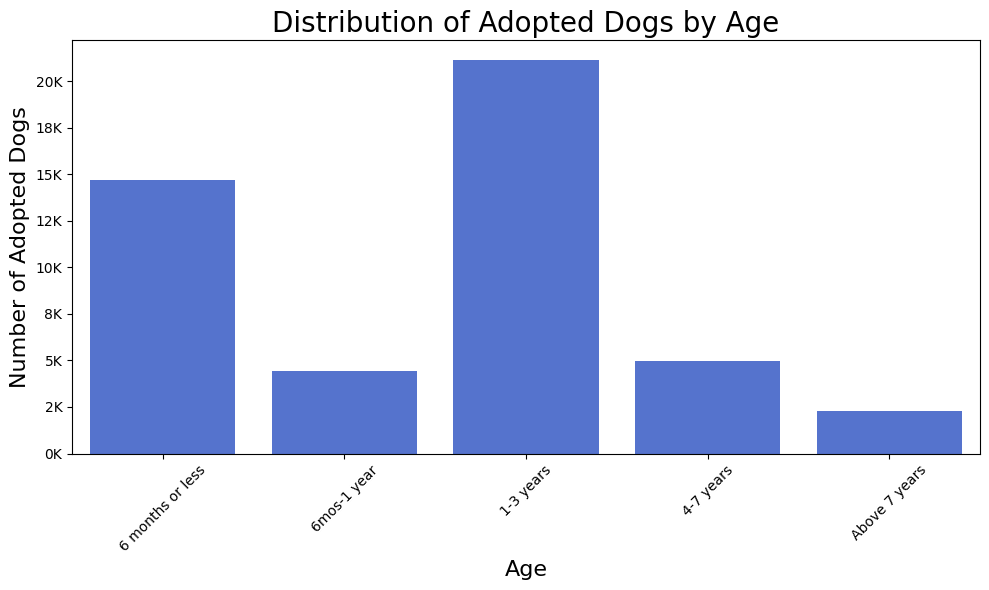

In [ ]:
adopted_dogs_age_counts = df_dogs[df_dogs['Adoption_Flag'] == True]['Age_Categorized'].value_counts().reindex(order)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=adopted_dogs_age_counts.index, y=adopted_dogs_age_counts.values, hue=adopted_dogs_age_counts.index,palette=["royalblue"] * len(adopted_dogs_age_counts), legend=False)

def y_fmt(y, pos):
    return f'{y/1000:.0f}K'

y_formatter = mticker.FuncFormatter(y_fmt)
ax.yaxis.set_major_formatter(y_formatter)

plt.title('Distribution of Adopted Dogs by Age', fontsize='20')
plt.xlabel('Age', fontsize='16')
plt.ylabel('Number of Adopted Dogs', fontsize='16')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

######Adoption Rate by Age

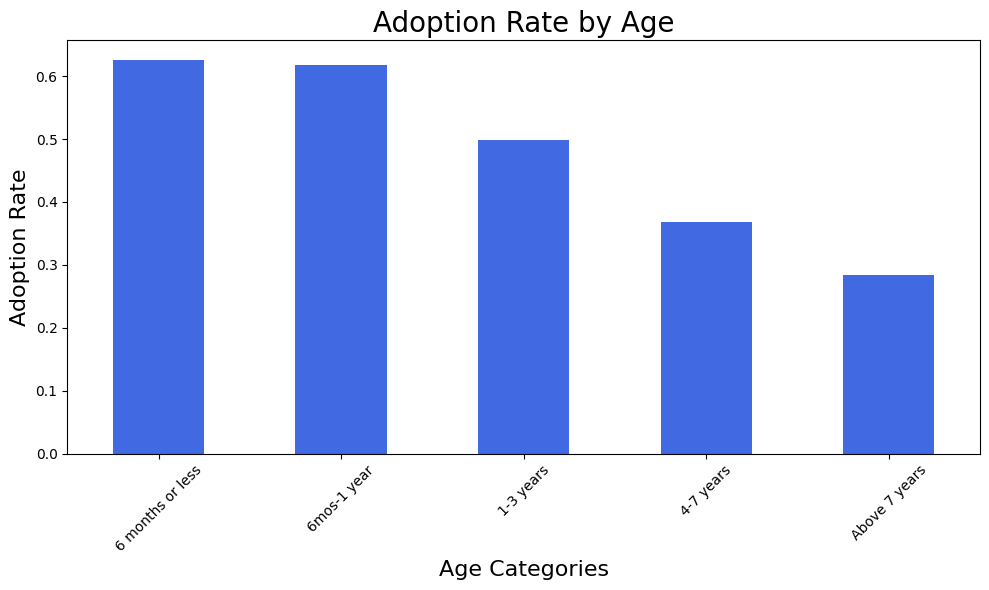

In [ ]:
#Adoption rate of age
adoption_rate_by_age = pd.crosstab(df_dogs.Age_Categorized, df_dogs.Adoption_Flag, normalize='index')[True]

#Change the Order
adoption_rate_by_age = adoption_rate_by_age.reindex(order)


plt.figure(figsize=(10, 6))

def y_fmt(y, pos):
    return f'{y/1000:.0f}K'

adoption_rate_by_age.plot.bar(color = 'royalblue')
plt.title("Adoption Rate by Age", fontsize = "20")
plt.xlabel('Age Categories', fontsize = "16")
plt.ylabel("Adoption Rate", fontsize = "16")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

###Distribution of Adopted Dogs by Gender:

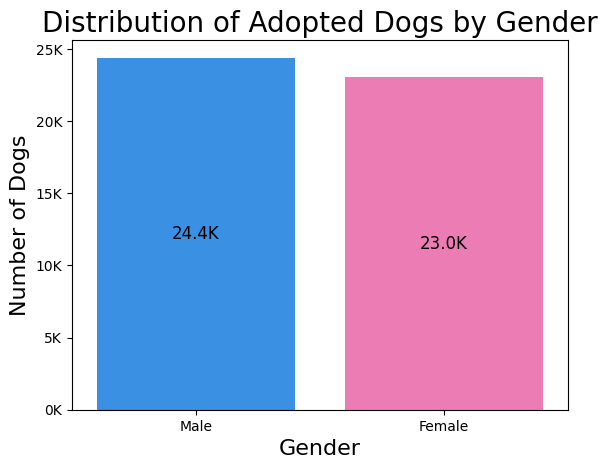

In [ ]:
# Filter for adopted dogs in general
adopted_dogs = df_dogs[df_dogs['Outcome_Type'] == 'Adoption'].copy()

# Extracting gender
gender_cleaned = [adopted_dogs['Sex_upon_Outcome'].str.contains('Male', na=False),
                  adopted_dogs['Sex_upon_Outcome'].str.contains('Female', na=False)]

choices = ['Male', 'Female']

# Apply numpy.select to create the new 'Gender' column
adopted_dogs['Gender'] = np.select(gender_cleaned, choices, default='Unknown')

# Get the distribution of gender
gender_distribution = adopted_dogs['Gender'].value_counts().reset_index()
gender_distribution.columns = ['Gender', 'Count']

# Remove 'Unknown' gender
gender_distribution = gender_distribution[gender_distribution['Gender'] != 'Unknown']

# Making the barplot
colors = {'Male': 'dodgerblue', 'Female': 'hotpink'}

gender_plot = sns.barplot(x='Gender', y='Count', hue ='Gender', data = gender_distribution, palette = colors, legend = False)

# Add labels to the bars
for p in gender_plot.patches:
    value = p.get_height()
    label = f'{value/1000:.1f}K'
    # Center the text label inside the bar
    gender_plot.annotate(label, (p.get_x() + p.get_width() / 2, p.get_height() / 2),
                ha='center', va='center', color='black', fontsize=12)

# Format y-axis labels to show 'K' for thousands
def y_fmt(y, pos):
    return f'{y/1000:.0f}K'

y_formatter = mticker.FuncFormatter(y_fmt)
gender_plot.yaxis.set_major_formatter(y_formatter)

plt.title('Distribution of Adopted Dogs by Gender', fontsize = "20")
plt.xlabel('Gender', fontsize="16")
plt.ylabel('Number of Dogs', fontsize="16")
plt.show()

###Adopted Dogs - Pre, During, and PostCOVID

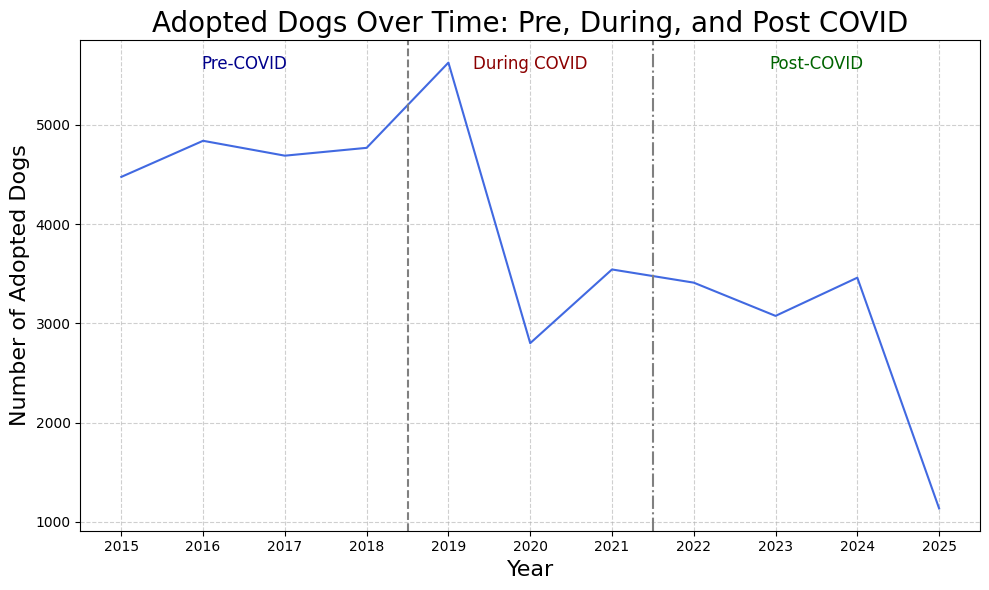

In [ ]:
# Filter for adopted dogs in general
adopted_dogs = df_dogs[df_dogs['Outcome_Type'] == 'Adoption'].copy()

adopted_dogs['Outcome_Year'] = adopted_dogs['Date_Time'].dt.year

# Creating the year groupings
pre_covid_years = range(2015, 2019)
during_covid_years = range(2019, 2022)
post_covid_years = range(2022, 2026)

pre_covid_adoptions = adopted_dogs[adopted_dogs['Outcome_Year'].isin(pre_covid_years)]
during_covid_adoptions = adopted_dogs[adopted_dogs['Outcome_Year'].isin(during_covid_years)]
post_covid_adoptions = adopted_dogs[adopted_dogs['Outcome_Year'].isin(post_covid_years)]

# Count adoptions per year for each period
pre_covid_counts = pre_covid_adoptions.groupby('Outcome_Year').size().rename('Count')
during_covid_counts = during_covid_adoptions.groupby('Outcome_Year').size().rename('Count')
post_covid_counts = post_covid_adoptions.groupby('Outcome_Year').size().rename('Count')

# Combine all counts into a DataFrame
all_adoptions_df = pd.concat([pre_covid_counts, during_covid_counts, post_covid_counts]).sort_index().reset_index()
all_adoptions_df.columns = ['Year', 'Number of Adopted Dogs']

# Plotting
plt.figure(figsize=(10, 6))
sns.lineplot(x='Year', y='Number of Adopted Dogs', data=all_adoptions_df, color='royalblue')

# Add vertical lines to separate periods
plt.axvline(x=2018.5, color='gray', linestyle='--', linewidth=1.5)
plt.axvline(x=2021.5, color='gray', linestyle='-.', linewidth=1.5)

# Add labels for the periods
ymin, ymax = plt.ylim()
y_text_pos = ymax * 0.95

plt.text(2016.5, y_text_pos, 'Pre-COVID', horizontalalignment='center', color='darkblue', fontsize=12)
plt.text(2020, y_text_pos, 'During COVID', horizontalalignment='center', color='darkred', fontsize=12)
plt.text(2023.5, y_text_pos, 'Post-COVID', horizontalalignment='center', color='darkgreen', fontsize=12)

plt.title('Adopted Dogs Over Time: Pre, During, and Post COVID', fontsize=20)
plt.xlabel('Year', fontsize=16)
plt.ylabel('Number of Adopted Dogs', fontsize=16)
plt.xticks(all_adoptions_df['Year'].unique())
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

####

```
# This is formatted as code
```

Adopted Dogs by Gender - Pre, During, and PostCOVID

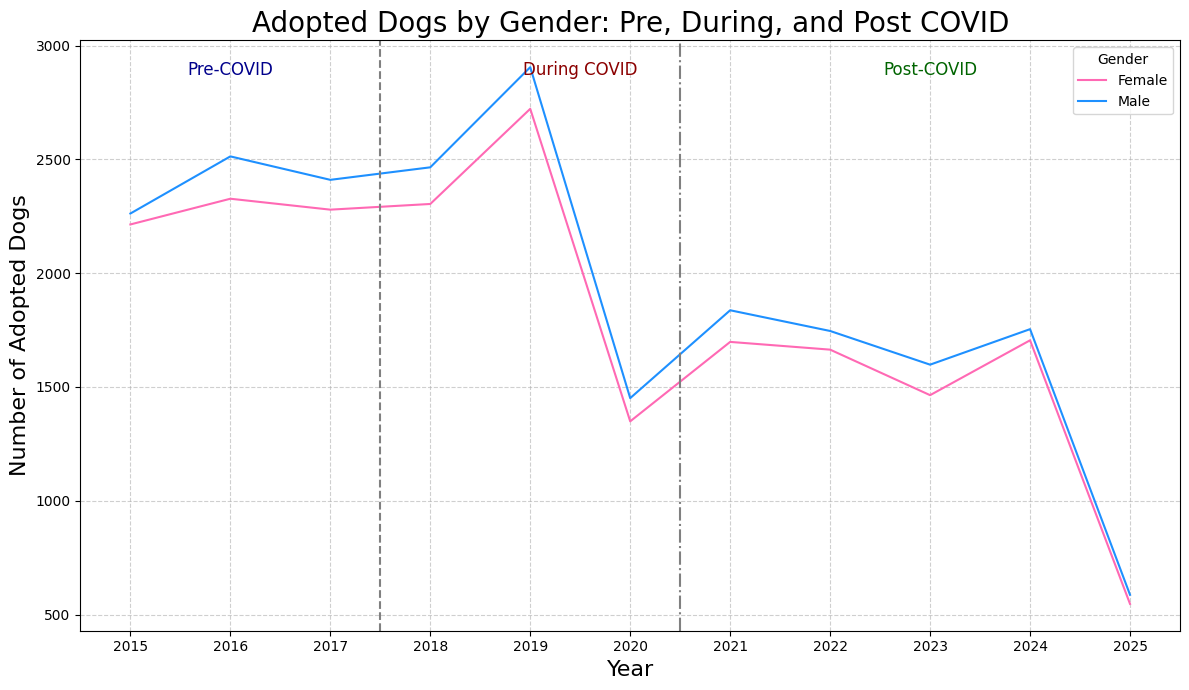

In [ ]:
# Filter for adopted dogs in general
adopted_dogs = df_dogs[df_dogs['Outcome_Type'] == 'Adoption'].copy()

adopted_dogs['Outcome_Year'] = adopted_dogs['Date_Time'].dt.year

gender_cleaned = [adopted_dogs['Sex_upon_Outcome'].str.contains('Male', na=False),
                  adopted_dogs['Sex_upon_Outcome'].str.contains('Female', na=False)]

choices = ['Male', 'Female']

adopted_dogs['Gender'] = np.select(gender_cleaned, choices, default='Unknown')

adopted_dogs_filtered_gender = adopted_dogs[adopted_dogs['Gender'] != 'Unknown'].copy()

all_adoptions_gender_df = adopted_dogs_filtered_gender.groupby(['Outcome_Year', 'Gender']).size().reset_index(name='Number of Adopted Dogs')

# Filter all_adoptions_gender_df to only include years from 2015 onwards
all_adoptions_gender_df = all_adoptions_gender_df[all_adoptions_gender_df['Outcome_Year'] >= 2015].copy()

# Define year groupings for clarity
pre_covid_years = range(2015, 2018)
during_covid_years = range(2019, 2021)
post_covid_years = range(2022, 2025)

# Plotting
plt.figure(figsize=(12, 7))
sns.lineplot(x='Outcome_Year', y='Number of Adopted Dogs', data=all_adoptions_gender_df, hue='Gender', palette={'Male': 'dodgerblue', 'Female': 'hotpink'})

# Add vertical lines to separate periods using the defined ranges
plt.axvline(x=max(pre_covid_years) + 0.5, color='gray', linestyle='--', linewidth=1.5)
plt.axvline(x=max(during_covid_years) + 0.5, color='gray', linestyle='-.', linewidth=1.5)

# Add labels for the periods
ymin, ymax = plt.ylim()
y_text_pos = ymax * 0.95

plt.text(sum(pre_covid_years)/len(pre_covid_years), y_text_pos, 'Pre-COVID', horizontalalignment='center', color='darkblue', fontsize=12)
plt.text(sum(during_covid_years)/len(during_covid_years), y_text_pos, 'During COVID', horizontalalignment='center', color='darkred', fontsize=12)
plt.text(sum(post_covid_years)/len(post_covid_years), y_text_pos, 'Post-COVID', horizontalalignment='center', color='darkgreen', fontsize=12)

plt.title('Adopted Dogs by Gender: Pre, During, and Post COVID', fontsize=20)
plt.xlabel('Year', fontsize=16)
plt.ylabel('Number of Adopted Dogs', fontsize=16)
plt.xticks(all_adoptions_gender_df['Outcome_Year'].unique())
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

#Logistic Regression Model

In [ ]:
df_dogs['Age_Categorized'] = df_dogs['Age_upon_Outcome'].map(age_map)

#Define the Order
order = ['6 months or less','6mos-1 year','1-3 years','4-7 years','Above 7 years']

###Defining Mixed Breeds

In [ ]:
#Defining Mixed Breeds
df_dogs['Mixed_Breed'] = df_dogs['Breed'].str.contains('Mix')

###Defining Outcome & Predictor Variables and Creating Model

In [ ]:
# outcome variable
y = df_dogs['Adoption_Flag']

# predictors
x = df_dogs[['Sex_upon_Outcome','Age_Categorized','Mixed_Breed','Is_Bully']]

# encode categorical predictors
x = pd.get_dummies(x, drop_first=True, dtype='int')

# partition data with train_x, valid_x, train_y, valid_y
train_x, valid_x, train_y, valid_y = train_test_split(x, y, test_size=0.4, random_state=1)

# fit the model with LogisticRegression() (training data)
# Predictive model
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(train_x, train_y)

LogisticRegression()

###Testing Model and creating coefficient table

In [ ]:
# use classificationSummary on valid_y and valid_pred, to get evaluations
# specify y_true=, and y_pred=
from mlba import classificationSummary

classificationSummary(y_true = valid_y, y_pred = model.predict(valid_x))

#Creating coefficient table
coef_table = pd.DataFrame({
    "Variable": x.columns,
    "Coefficient": model.coef_[0]
}).sort_values(by="Coefficient", ascending=False)

print(coef_table)

Confusion Matrix (Accuracy 0.7481)

       Prediction
Actual False  True
 False 12453  6447
  True  3071 15811
                           Variable  Coefficient
4    Sex_upon_Outcome_Spayed Female     3.939112
3    Sex_upon_Outcome_Neutered Male     3.726510
7  Age_Categorized_6 months or less     1.392332
8       Age_Categorized_6mos-1 year     0.611912
2      Sex_upon_Outcome_Intact Male    -0.112681
1                          Is_Bully    -0.134367
0                       Mixed_Breed    -0.178861
6         Age_Categorized_4-7 years    -0.757451
5          Sex_upon_Outcome_Unknown    -0.957377
9     Age_Categorized_Above 7 years    -1.162294


###Odds Ration (code help from AI [chat gpt])

In [ ]:
#Odds Ratio

odds_ratios = pd.DataFrame({
    "Variable": x.columns,
    "Odds_Ratio": np.exp(model.coef_[0])
})

print(x.columns)
print(odds_ratios)

Index(['Mixed_Breed', 'Is_Bully', 'Sex_upon_Outcome_Intact Male',
       'Sex_upon_Outcome_Neutered Male', 'Sex_upon_Outcome_Spayed Female',
       'Sex_upon_Outcome_Unknown', 'Age_Categorized_4-7 years',
       'Age_Categorized_6 months or less', 'Age_Categorized_6mos-1 year',
       'Age_Categorized_Above 7 years'],
      dtype='object')
                           Variable  Odds_Ratio
0                       Mixed_Breed    0.836223
1                          Is_Bully    0.874269
2      Sex_upon_Outcome_Intact Male    0.893436
3    Sex_upon_Outcome_Neutered Male   41.533917
4    Sex_upon_Outcome_Spayed Female   51.372983
5          Sex_upon_Outcome_Unknown    0.383898
6         Age_Categorized_4-7 years    0.468860
7  Age_Categorized_6 months or less    4.024222
8       Age_Categorized_6mos-1 year    1.843953
9     Age_Categorized_Above 7 years    0.312768


###Measuring the Metrics of the Model

In [ ]:
#Metrics from the Model

TP = 15936
TN = 12366
FP = 6367
FN = 3117

accuracy = (TP + TN) / (TP + TN + FP + FN)
recall = TP / (TP + FN)
precision = TP / (TP + FP)
specificity = TN / (TN + FP)
f1 = 2 * (precision * recall) / (precision + recall)

print("Accuracy:", accuracy)
print("Recall:", recall)
print("Precision:", precision)
print("Specificity:", specificity)
print("F1 Score:", f1)

Accuracy: 0.7490075689408776
Recall: 0.8364037159502441
Precision: 0.7145227099493342
Specificity: 0.6601185074467517
F1 Score: 0.7706741464358255
